In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## U-Net Architecture
Plain U-Net (4 levels, widths 32/64/128/256, bottleneck 512) with dropout in the deepest encoder block, the bottleneck and the decoder.

In [20]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, dropout_rate=0.1, use_dropout=True):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if use_dropout:
            layers.append(nn.Dropout2d(dropout_rate))
        
        layers.extend([
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ])
        if use_dropout:
            layers.append(nn.Dropout2d(dropout_rate))
        
        self.double_conv = nn.Sequential(*layers)

    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[32, 64, 128, 256], dropout_rate=0.15):
        super().__init__()
        
        self.enc1 = DoubleConv(in_channels, features[0], dropout_rate, use_dropout=False)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(features[0], features[1], dropout_rate, use_dropout=False)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = DoubleConv(features[1], features[2], dropout_rate, use_dropout=False)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = DoubleConv(features[2], features[3], dropout_rate=0.15, use_dropout=True)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(features[3], features[3]*2, dropout_rate=0.2, use_dropout=True)

        self.up4 = nn.ConvTranspose2d(features[3]*2, features[3], kernel_size=2, stride=2)
        self.dec4 = DoubleConv(features[3]*2, features[3], dropout_rate, use_dropout=True)
        self.up3 = nn.ConvTranspose2d(features[3], features[2], kernel_size=2, stride=2)
        self.dec3 = DoubleConv(features[2]*2, features[2], dropout_rate, use_dropout=True)
        self.up2 = nn.ConvTranspose2d(features[2], features[1], kernel_size=2, stride=2)
        self.dec2 = DoubleConv(features[1]*2, features[1], dropout_rate, use_dropout=True)
        self.up1 = nn.ConvTranspose2d(features[1], features[0], kernel_size=2, stride=2)
        self.dec1 = DoubleConv(features[0]*2, features[0], dropout_rate, use_dropout=True)

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x); p1 = self.pool1(e1)
        e2 = self.enc2(p1); p2 = self.pool2(e2)
        e3 = self.enc3(p2); p3 = self.pool3(e3)
        e4 = self.enc4(p3); p4 = self.pool4(e4)
        
        b = self.bottleneck(p4)
        
        d4 = self.up4(b); d4 = torch.cat([d4, e4], dim=1); d4 = self.dec4(d4)
        d3 = self.up3(d4); d3 = torch.cat([d3, e3], dim=1); d3 = self.dec3(d3)
        d2 = self.up2(d3); d2 = torch.cat([d2, e2], dim=1); d2 = self.dec2(d2)
        d1 = self.up1(d2); d1 = torch.cat([d1, e1], dim=1); d1 = self.dec1(d1)
        
        out = self.final_conv(d1)
        return out


## Dataset and Data Loading

In [21]:
IMG_EXTS = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')

class SegDataset(Dataset):
    """Reads from a pre-made split folder that already contains 'img/' and 'mask/'
    subfolders (e.g. root_dir/train/Img, root_dir/train/Masks). Mask files are named
    '<stem>_mask.<ext>' (folder-name case is ignored)."""
    def __init__(self, root_dir, split='train', transform=None, img_size=(256, 256)):
        self.root_dir = root_dir
        self.split = split
        self.img_size = img_size
        self.transform = transform

        split_dir = os.path.join(root_dir, split)
        # case-insensitive lookup so 'Img' / 'img' and 'Masks' / 'masks' all work
        def _sub(name):
            for d in os.listdir(split_dir):
                if d.lower() == name:
                    return os.path.join(split_dir, d)
            raise FileNotFoundError(f"'{name}' folder not found in {split_dir}: {os.listdir(split_dir)}")
        self.img_dir = _sub('img')
        self.mask_dir = _sub('masks')

        mask_stems = {os.path.splitext(f)[0].replace('_mask', ''): f
                      for f in os.listdir(self.mask_dir) if f.lower().endswith(IMG_EXTS)}

        self.pairs = []
        for f in sorted(os.listdir(self.img_dir)):
            if not f.lower().endswith(IMG_EXTS):
                continue
            stem = os.path.splitext(f)[0]
            if stem in mask_stems:
                self.pairs.append((f, mask_stems[stem]))

        assert len(self.pairs) > 0, f"No image/mask pairs found under {split_dir}"

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_name, mask_name = self.pairs[idx]

        img = Image.open(os.path.join(self.img_dir, img_name)).convert('RGB')
        label = Image.open(os.path.join(self.mask_dir, mask_name)).convert('L')

        img = img.resize(self.img_size)
        label = label.resize(self.img_size, Image.NEAREST)

        if self.transform:
            img = self.transform(img)
        else:
            img = transforms.ToTensor()(img)

        label = torch.from_numpy((np.array(label) > 0).astype(np.float32)).unsqueeze(0)

        return img, label


## Loss Functions and Metrics

In [22]:
def dice_coef(pred, target, smooth=1e-6):
    pred = pred.contiguous()
    target = target.contiguous()
    intersection = (pred * target).sum(dim=(2,3))
    denom = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))
    dice = (2. * intersection + smooth) / (denom + smooth)
    return dice.mean()

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        dice = dice_coef(pred, target, smooth=self.smooth)
        return 1.0 - dice

def combined_loss(logits, mask, bce_weight=0.6, dice_weight=0.4):
    bce_loss = nn.BCEWithLogitsLoss()
    bce = bce_loss(logits, mask)
    probs = torch.sigmoid(logits)
    dice = DiceLoss()(probs, mask)
    return bce_weight * bce + dice_weight * dice

@torch.no_grad()
def compute_metrics_batch(logits, masks, thresh=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs >= thresh).float()
    preds_flat = preds.view(-1).cpu().numpy()
    masks_flat = masks.view(-1).cpu().numpy()
    
    unique_preds = np.unique(preds_flat)
    unique_masks = np.unique(masks_flat)
    
    if len(unique_preds) == 1 and len(unique_masks) == 1:
        if unique_preds[0] == unique_masks[0]:
            if unique_preds[0] == 1:
                tp, fp, fn, tn = len(preds_flat), 0, 0, 0
            else:
                tp, fp, fn, tn = 0, 0, 0, len(preds_flat)
        else:
            if unique_preds[0] == 1:
                tp, fp, fn, tn = 0, len(preds_flat), 0, 0
            else:
                tp, fp, fn, tn = 0, 0, len(preds_flat), 0
    else:
        cm = confusion_matrix(masks_flat, preds_flat, labels=[0,1])
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
        else:
            if cm.shape == (1, 1):
                if unique_masks[0] == 0:
                    tn, fp, fn, tp = cm[0,0], 0, 0, 0
                else:
                    tn, fp, fn, tp = 0, 0, 0, cm[0,0]
            else:
                tn, fp, fn, tp = 0, 0, 0, 0
    
    eps = 1e-8
    iou = tp / (tp + fp + fn + eps)
    dice = (2 * tp) / (2 * tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    acc = (tp + tn) / (tp + tn + fp + fn + eps)
    
    iou_background = tn / (tn + fp + fn + eps)
    iou_damage = tp / (tp + fp + fn + eps)
    miou = (iou_background + iou_damage) / 2
    
    return {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
            "iou": float(iou), "dice": float(dice), "precision": float(precision),
            "recall": float(recall), "f1": float(f1), "acc": float(acc), "miou": float(miou)}

## Training and Validation Functions

In [23]:
import copy

class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_loss = None
        self.counter = 0
        self.best_weights = None
        
    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.save_checkpoint(model)
        else:
            self.counter += 1
            
        if self.counter >= self.patience:
            if self.restore_best_weights:
                model.load_state_dict(self.best_weights)
            return True
        return False
    
    def save_checkpoint(self, model):
        self.best_weights = copy.deepcopy(model.state_dict())

def train_one_epoch(model, loader, optimizer):
    model.train()
    running_loss = 0.0
    agg = {"tn":0,"fp":0,"fn":0,"tp":0}
    
    for imgs, masks in tqdm(loader, desc="Train batch"):
        imgs = imgs.to(device)
        masks = masks.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = combined_loss(logits, masks)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        
        mets = compute_metrics_batch(logits, masks)
        for k in ["tn","fp","fn","tp"]:
            agg[k] += mets[k]
    
    tp, fp, fn, tn = agg["tp"], agg["fp"], agg["fn"], agg["tn"]
    train_acc = (tp + tn) / (tp + tn + fp + fn + 1e-8)
    
    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss, train_acc

@torch.no_grad()
def validate(model, loader):
    model.eval()
    running_loss = 0.0
    agg = {"tn":0,"fp":0,"fn":0,"tp":0}
    
    for imgs, masks in tqdm(loader, desc="Val batch"):
        imgs = imgs.to(device)
        masks = masks.to(device)
        logits = model(imgs)
        loss = combined_loss(logits, masks)
        running_loss += loss.item() * imgs.size(0)
        mets = compute_metrics_batch(logits, masks)
        for k in ["tn","fp","fn","tp"]:
            agg[k] += mets[k]
    
    tp, fp, fn, tn = agg["tp"], agg["fp"], agg["fn"], agg["tn"]
    eps = 1e-8
    iou = tp / (tp + fp + fn + eps)
    dice = (2 * tp) / (2 * tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    acc = (tp + tn) / (tp + tn + fp + fn + eps)
    
    iou_background = tn / (tn + fp + fn + eps)
    iou_damage = tp / (tp + fp + fn + eps)
    miou = (iou_background + iou_damage) / 2
    
    epoch_loss = running_loss / len(loader.dataset)
    metrics = {"loss": epoch_loss, "iou": iou, "dice": dice, "precision": precision,
               "recall": recall, "f1": f1, "acc": acc, "miou": miou,
               "confusion": np.array([[tn, fp], [fn, tp]])}
    return metrics

def train_model(model, train_loader, val_loader, num_epochs=200, learning_rate=2e-4, patience=10):
    decay, no_decay = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if p.ndim == 1 or name.endswith(".bias"):
            no_decay.append(p)
        else:
            decay.append(p)

    optimizer = optim.AdamW(
        [
            {"params": decay, "weight_decay": 1e-3},
            {"params": no_decay, "weight_decay": 0.0},
        ],
        lr=learning_rate,
    )
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.7, patience=7, min_lr=1e-6
    )
    
    early_stopping = EarlyStopping(patience=patience, min_delta=1e-4)
    
    train_losses = []
    val_losses = []
    val_ious = []
    val_dices = []
    train_accs = []
    val_accs = []
    
    best_val_loss = float('inf')
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer)
        
        val_metrics = validate(model, val_loader)
        
        scheduler.step(val_metrics['loss'])
        
        print(f"Train Loss: {train_loss:.6f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_metrics['loss']:.6f} | Val Acc: {val_metrics['acc']:.4f} | IoU: {val_metrics['iou']:.4f} | Dice: {val_metrics['dice']:.4f} | F1: {val_metrics['f1']:.4f}")
        print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.2e}")
        
        train_losses.append(train_loss)
        val_losses.append(val_metrics['loss'])
        val_ious.append(val_metrics['iou'])
        val_dices.append(val_metrics['dice'])
        train_accs.append(train_acc)
        val_accs.append(val_metrics['acc'])
        
        if val_metrics['loss'] < best_val_loss - 1e-4:
            best_val_loss = val_metrics['loss']
            torch.save(model.state_dict(), 'BSP_UNet.pth')
            print(f"Saved best model with validation loss: {best_val_loss:.6f}")
        
        if early_stopping(val_metrics['loss'], model):
            print(f'Early stopping triggered after {epoch+1} epochs')
            break
    
    return train_losses, val_losses, val_ious, val_dices, train_accs, val_accs

## Training Configuration and Execution


In [24]:
def main():
    # Hyperparameters
    BATCH_SIZE = 4
    LEARNING_RATE = 2e-4
    NUM_EPOCHS = 30
    PATIENCE = 3
    IMG_SIZE = (256, 256)
    
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # folder that contains train/, val/, test/ — each with its own img/ and mask/ subfolders
    # (use 'train_augmented' if that's what you uploaded as your train split)
    root_dir = "/kaggle/input/datasets/dewangchoudhary/bangaloresolarpanels/BangaloreSolarPanels"
    
    train_dataset = SegDataset(root_dir, split='train', transform=transform, img_size=IMG_SIZE)
    val_dataset = SegDataset(root_dir, split='val', transform=transform, img_size=IMG_SIZE)
    test_dataset = SegDataset(root_dir, split='test', transform=transform, img_size=IMG_SIZE)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0, pin_memory=True)
    
    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    print(f"Test samples: {len(test_dataset)}")
    
    # dropout as U-Net: encoder block 4 = 0.15, bottleneck = 0.2, decoder = 0.15 (built into the model)
    FEATURES = [32, 64, 128, 256]
    DROPOUT_RATE = 0.15
    
    model = UNet(in_channels=3, out_channels=1, features=FEATURES, dropout_rate=DROPOUT_RATE).to(device)
    
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params:,}")
    
    print("\nStarting UNet training")
    print(f"Learning Rate: {LEARNING_RATE}")
    print(f"Weight Decay: 1e-3")
    print(f"Dropout: enc4=0.15, bottleneck=0.2, decoder={DROPOUT_RATE}")
    print(f"Threshold: 0.5")
    print(f"Scheduler: ReduceLROnPlateau (factor=0.7, patience=7)\n")
    
    train_losses, val_losses, val_ious, val_dices, train_accs, val_accs = train_model(
        model, train_loader, val_loader, NUM_EPOCHS, LEARNING_RATE, PATIENCE
    )
    
    return model, train_losses, val_losses, val_ious, val_dices, train_accs, val_accs, test_loader

model, train_losses, val_losses, val_ious, val_dices, train_accs, val_accs, test_loader = main()

Training samples: 20
Validation samples: 10
Test samples: 13
Total parameters: 7,763,041

Starting UNet training
Learning Rate: 0.0002
Weight Decay: 1e-3
Dropout: enc4=0.15, bottleneck=0.2, decoder=0.15
Threshold: 0.5
Scheduler: ReduceLROnPlateau (factor=0.7, patience=7)


Epoch 1/30


Val batch: 100%|██████████| 5/5 [00:00<00:00, 38.96it/s]


Train Loss: 0.837109 | Train Acc: 0.4514
Val Loss: 0.764434 | Val Acc: 0.9589 | IoU: 0.0000 | Dice: 0.0000 | F1: 0.0000
Learning Rate: 2.00e-04
Saved best model with validation loss: 0.764434

Epoch 2/30


Val batch: 100%|██████████| 5/5 [00:00<00:00, 36.46it/s]


Train Loss: 0.797834 | Train Acc: 0.6140
Val Loss: 0.762306 | Val Acc: 0.9588 | IoU: 0.0003 | Dice: 0.0006 | F1: 0.0006
Learning Rate: 2.00e-04
Saved best model with validation loss: 0.762306

Epoch 3/30


...

Train Loss: 0.591585 | Train Acc: 0.9920
Val Loss: 0.635410 | Val Acc: 0.9434 | IoU: 0.4192 | Dice: 0.5908 | F1: 0.5908
Learning Rate: 2.00e-04

Epoch 15/30


Val batch: 100%|██████████| 5/5 [00:00<00:00, 36.00it/s]


Train Loss: 0.591711 | Train Acc: 0.9893
Val Loss: 0.589697 | Val Acc: 0.9668 | IoU: 0.5513 | Dice: 0.7107 | F1: 0.7107
Learning Rate: 2.00e-04

Epoch 16/30


Val batch: 100%|██████████| 5/5 [00:00<00:00, 37.38it/s]

Train Loss: 0.590162 | Train Acc: 0.9918
Val Loss: 0.609316 | Val Acc: 0.9655 | IoU: 0.1608 | Dice: 0.2771 | F1: 0.2771
Learning Rate: 2.00e-04
Early stopping triggered after 16 epochs


## Visualization of Training Progress

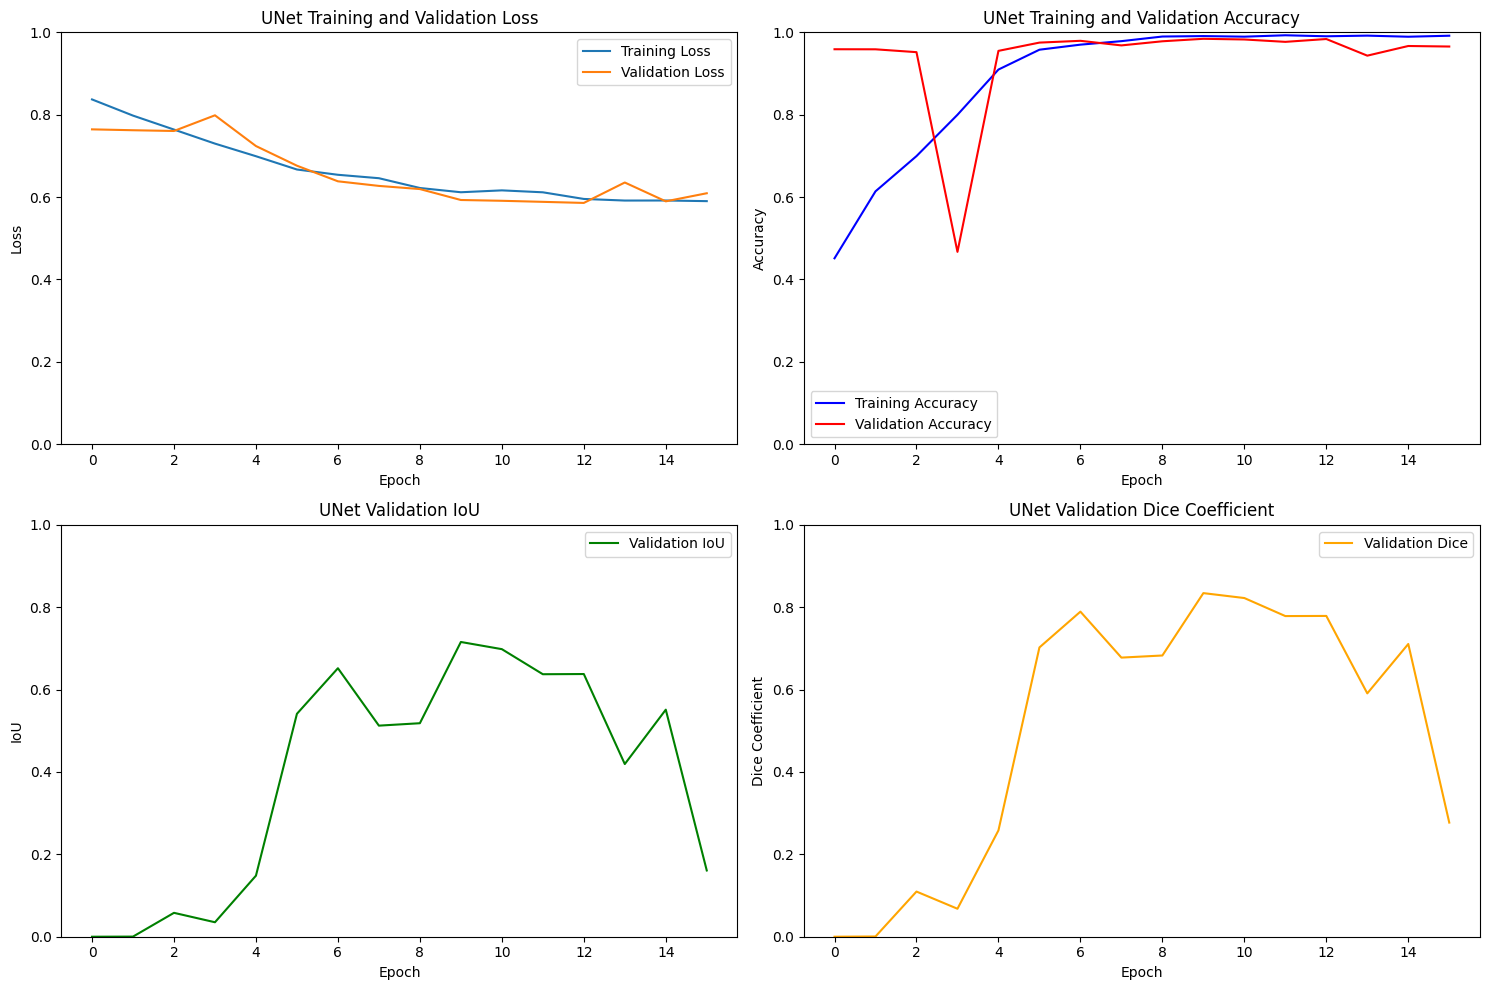

In [25]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

ax1.plot(train_losses, label='Training Loss')
ax1.plot(val_losses, label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_ylim(0, 1)
ax1.legend()
ax1.set_title('UNet Training and Validation Loss')

ax2.plot(train_accs, label='Training Accuracy', color='blue')
ax2.plot(val_accs, label='Validation Accuracy', color='red')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.set_title('UNet Training and Validation Accuracy')

ax3.plot(val_ious, label='Validation IoU', color='green')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('IoU')
ax3.set_ylim(0, 1)
ax3.legend()
ax3.set_title('UNet Validation IoU')

ax4.plot(val_dices, label='Validation Dice', color='orange')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Dice Coefficient')
ax4.set_ylim(0, 1)
ax4.legend()
ax4.set_title('UNet Validation Dice Coefficient')

plt.tight_layout()
plt.savefig('BSP_UNet_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

## Test Evaluation

Loading best UNet model for test evaluation...

Evaluating UNet on test set...


Val batch: 100%|██████████| 13/13 [00:00<00:00, 54.59it/s]



TEST EVALUATION METRICS
Configuration: UNet | dropout as U-Net: encoder block 4 = 0.15, bottleneck = 0.2, decoder = 0.15
Test set processed with batch_size=1
Loss:            0.584839
IoU:             0.6678
mIoU:            0.8257
Dice Coefficient: 0.8008
Accuracy:        0.9841
Precision:       0.8894
Recall:          0.7282
F1-Score:        0.8008
Confusion matrix (pixel-level):
[[811259   3381]
 [ 10144  27184]]


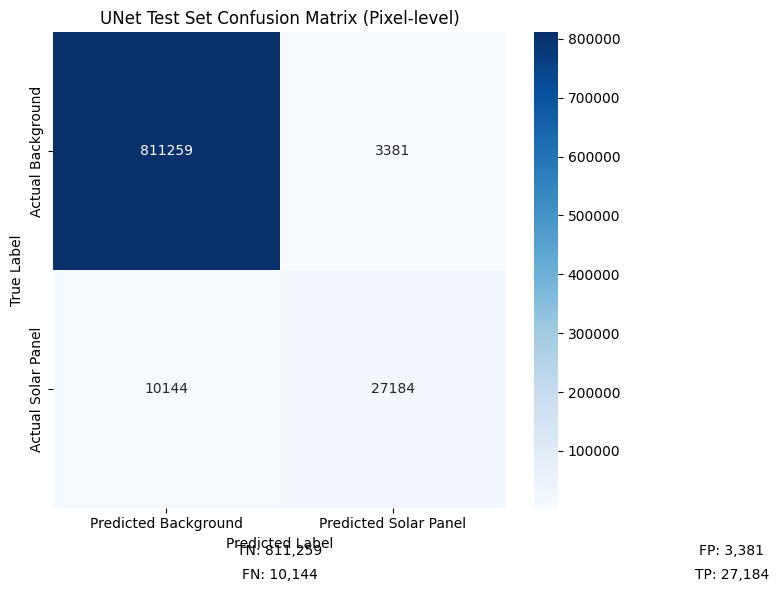

UNet training and evaluation completed!


In [26]:
print("Loading best UNet model for test evaluation...")
model.load_state_dict(torch.load('BSP_UNet.pth', map_location=device))
model.to(device)

print("\nEvaluating UNet on test set...")
test_metrics = validate(model, test_loader)

print("\n" + "="*50)
print("TEST EVALUATION METRICS")
print("Configuration: UNet | dropout as U-Net: encoder block 4 = 0.15, bottleneck = 0.2, decoder = 0.15")
print("="*50)
print(f"Test set processed with batch_size=1")
print(f"Loss:            {test_metrics['loss']:.6f}")
print(f"IoU:             {test_metrics['iou']:.4f}")
print(f"mIoU:            {test_metrics['miou']:.4f}")
print(f"Dice Coefficient: {test_metrics['dice']:.4f}")
print(f"Accuracy:        {test_metrics['acc']:.4f}")
print(f"Precision:       {test_metrics['precision']:.4f}")
print(f"Recall:          {test_metrics['recall']:.4f}")
print(f"F1-Score:        {test_metrics['f1']:.4f}")
print("Confusion matrix (pixel-level):")
print(test_metrics["confusion"])
print("="*50)

plt.figure(figsize=(8, 6))
cm = test_metrics["confusion"]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Background', 'Predicted Solar Panel'],
            yticklabels=['Actual Background', 'Actual Solar Panel'])
plt.title('UNet Test Set Confusion Matrix (Pixel-level)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.text(0.5, -0.1, f'TN: {cm[0,0]:,}', ha='center', transform=plt.gca().transAxes)
plt.text(1.5, -0.1, f'FP: {cm[0,1]:,}', ha='center', transform=plt.gca().transAxes)
plt.text(0.5, -0.15, f'FN: {cm[1,0]:,}', ha='center', transform=plt.gca().transAxes)
plt.text(1.5, -0.15, f'TP: {cm[1,1]:,}', ha='center', transform=plt.gca().transAxes)

plt.tight_layout()
plt.savefig('BSP_UNet_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("UNet training and evaluation completed!")


## Test the model on images

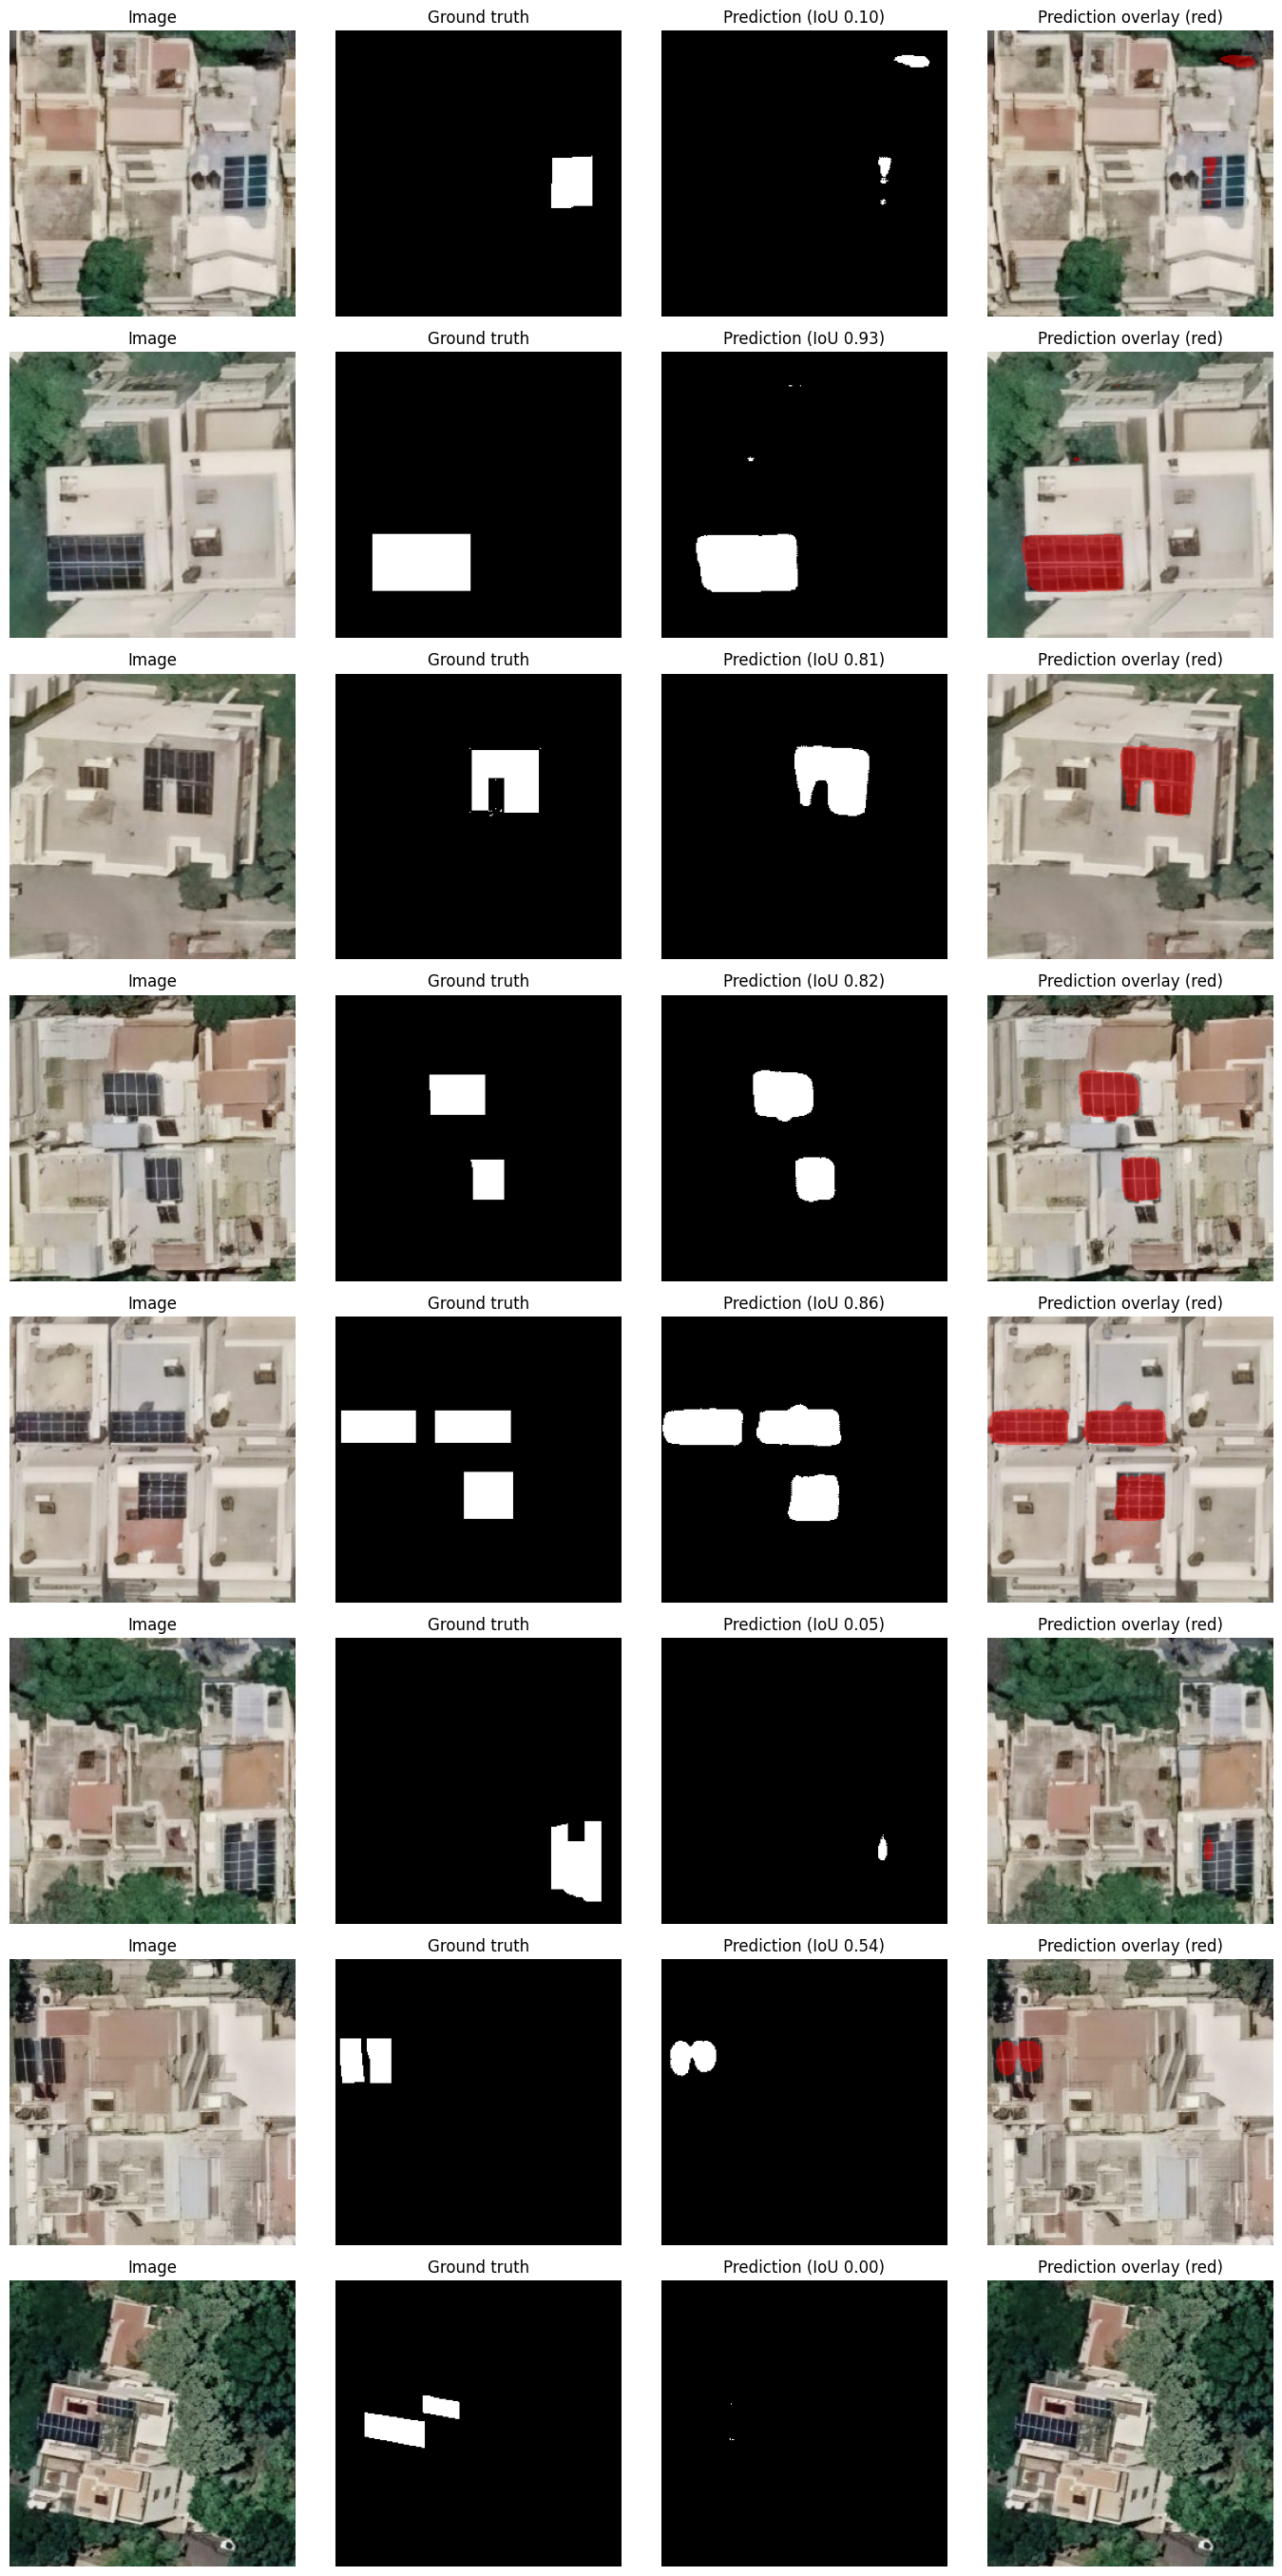

In [27]:
import random

root_dir = '/kaggle/input/datasets/dewangchoudhary/bangaloresolarpanels/BangaloreSolarPanels'
IMG_SIZE = (256, 256)
FEATURES = [32, 64, 128, 256]
DROPOUT_RATE = 0.15
CKPT = 'BSP_UNet.pth'

# rebuild the test set and load the best checkpoint
tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
test_ds = SegDataset(root_dir, split='test', transform=tf, img_size=IMG_SIZE)

net = UNet(in_channels=3, out_channels=1, features=FEATURES, dropout_rate=DROPOUT_RATE).to(device)
net.load_state_dict(torch.load(CKPT, map_location=device))
net.eval()

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def show_predictions(n=8, seed=0, thresh=0.5):
    random.seed(seed)
    idxs = random.sample(range(len(test_ds)), n)
    fig, axes = plt.subplots(n, 4, figsize=(14, 3.4 * n))
    for r, i in enumerate(idxs):
        img, gt = test_ds[i]
        with torch.no_grad():
            prob = torch.sigmoid(net(img.unsqueeze(0).to(device)))[0, 0].cpu()
        pred = (prob >= thresh).float()

        rgb = (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
        gt_np, pred_np = gt[0].numpy(), pred.numpy()

        inter = (gt_np * pred_np).sum()
        union = gt_np.sum() + pred_np.sum() - inter
        iou = inter / union if union > 0 else float('nan')

        overlay = rgb.copy()
        overlay[pred_np > 0] = 0.5 * overlay[pred_np > 0] + 0.5 * np.array([1, 0, 0])

        axes[r, 0].imshow(rgb);                  axes[r, 0].set_title("Image")
        axes[r, 1].imshow(gt_np, cmap='gray');   axes[r, 1].set_title("Ground truth")
        axes[r, 2].imshow(pred_np, cmap='gray'); axes[r, 2].set_title(f"Prediction (IoU {iou:.2f})")
        axes[r, 3].imshow(overlay);              axes[r, 3].set_title("Prediction overlay (red)")
        for a in axes[r]: a.axis('off')
    plt.tight_layout()
    plt.savefig('BSP_UNet_predictions.png', dpi=200, bbox_inches='tight')
    plt.show()

show_predictions(n=8, seed=0)
